In [42]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import matplotlib.font_manager as fm

#matplot에 사용할 기본 폰트
from matplotlib import rcParams
rcParams['font.family'] = 'AppleGothic'
rcParams['axes.unicode_minus'] = False #음수 허용

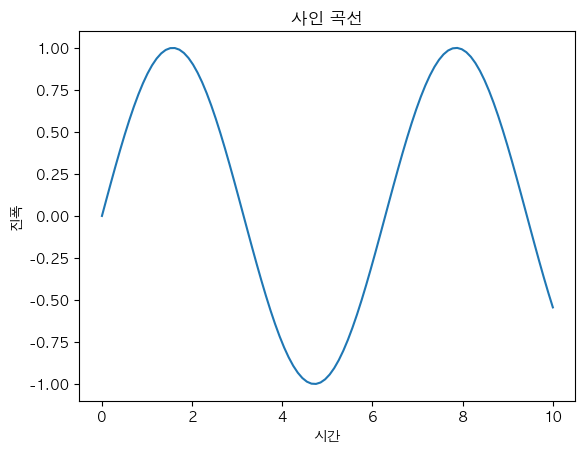

In [43]:
x = np.linspace(0,10,100)
y=np.sin(x)
plt.title('사인 곡선')
plt.xlabel('시간')
plt.ylabel('진폭')
plt.plot(x,y)

# 1. 데이터 시각화의 중요성


In [48]:
import seaborn as sns
anscombe = sns.load_dataset('anscombe')
anscombe

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


In [54]:
anscombe.dataset.unique()

array(['I', 'II', 'III', 'IV'], dtype=object)

# 2. Matplotlib 라이브러리 

In [63]:
d1 = anscombe[anscombe.dataset == 'I']
d2 = anscombe[anscombe.dataset == 'II']
d3 = anscombe[anscombe.dataset == 'III']
d4 = anscombe[anscombe.dataset == 'IV']
d1.shape, d2.shape, d3.shape , d4.shape

((11, 3), (11, 3), (11, 3), (11, 3))

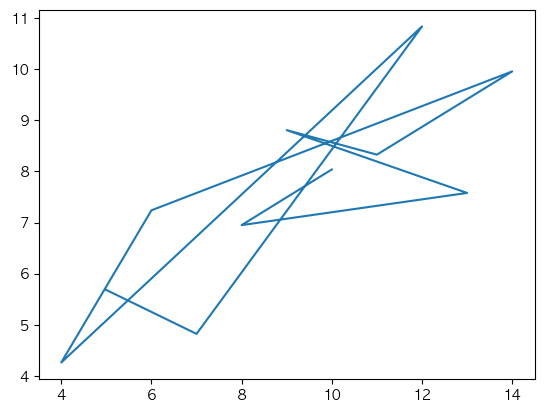

In [59]:
plt.plot(d1.x,d1.y)
plt.show()

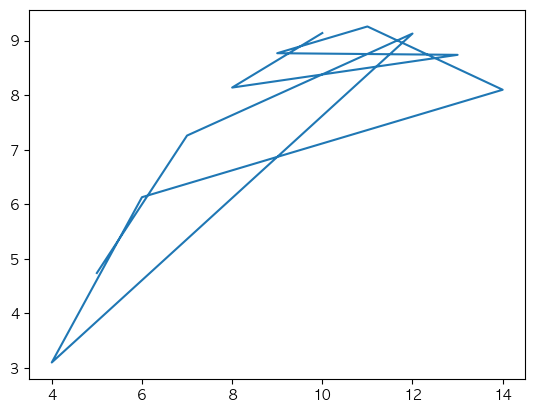

In [65]:
plt.plot(d2.x,d2.y)
plt.show()

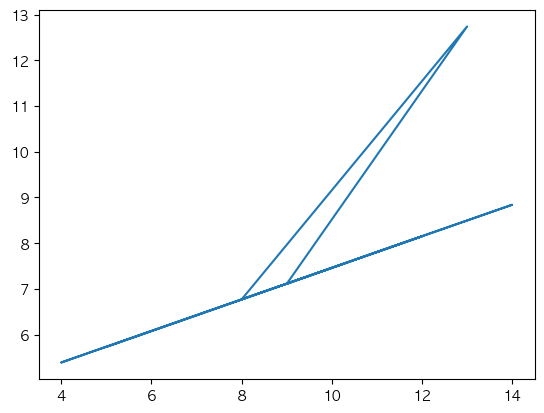

In [66]:
plt.plot(d3.x,d3.y)
plt.show()

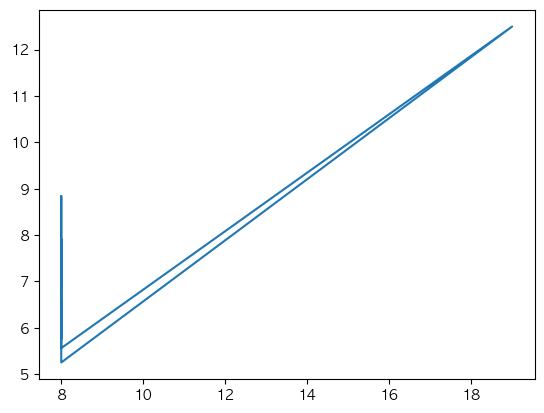

In [67]:
plt.plot(d4.x,d4.y)
plt.show()

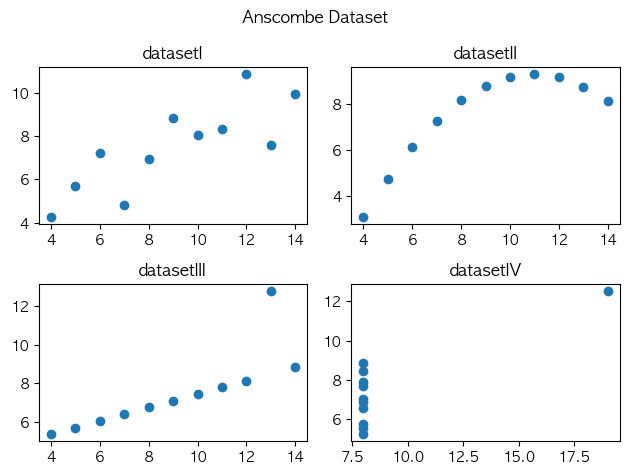

In [78]:
fig = plt.figure()
axes1 = fig.add_subplot(2,2,1) #2row, rcol, position
axes2 = fig.add_subplot(2,2,2)
axes3 = fig.add_subplot(2,2,3)
axes4 = fig.add_subplot(2,2,4)

axes1.plot(d1.x,d1.y,'o')
axes2.plot(d2.x,d2.y,'o')
axes3.plot(d3.x,d3.y,'o')
axes4.plot(d4.x,d4.y,'o')

fig.suptitle('Anscombe Dataset')

axes1.set_title('datasetI')
axes2.set_title('datasetII')
axes3.set_title('datasetIII')
axes4.set_title('datasetIV')

fig.set_tight_layout(True)

# plt.show()


In [86]:
tips=sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1. 일변향 그래프

-히스토그램: 연속형 변수의 구간별 분포/ x: 구간 y: 빈도수 

(array([ 1.,  1.,  5.,  5., 20., 17., 24., 18., 26., 23., 15., 13., 11.,
        13.,  7.,  7.,  7.,  5.,  5.,  5.,  2.,  2.,  2.,  3.,  0.,  2.,
         1.,  0.,  3.,  1.]),
 array([ 3.07      ,  4.66133333,  6.25266667,  7.844     ,  9.43533333,
        11.02666667, 12.618     , 14.20933333, 15.80066667, 17.392     ,
        18.98333333, 20.57466667, 22.166     , 23.75733333, 25.34866667,
        26.94      , 28.53133333, 30.12266667, 31.714     , 33.30533333,
        34.89666667, 36.488     , 38.07933333, 39.67066667, 41.262     ,
        42.85333333, 44.44466667, 46.036     , 47.62733333, 49.21866667,
        50.81      ]),
 <BarContainer object of 30 artists>)

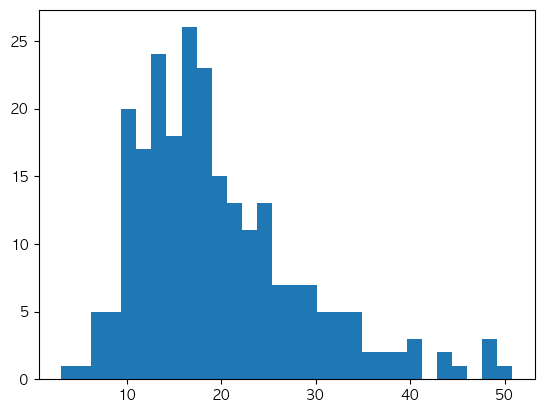

In [93]:
fig = plt.figure()
axes =fig.add_subplot(1,1,1)
axes.hist(data = tips, x='total_bill', bins = 30)

- Box plot

연속형 변수의 분포를 나타냄, 최대/최소/중앙값과 사분위를 표시

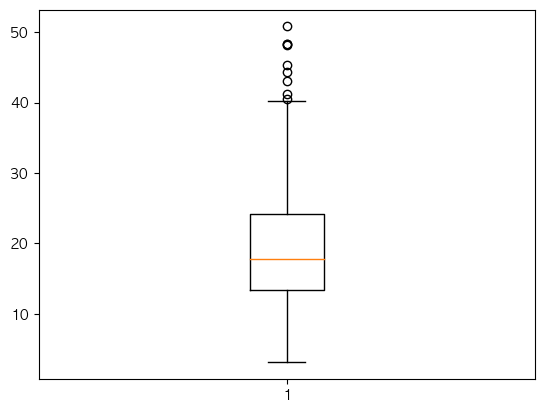

In [116]:
fig = plt.figure()
axes =fig.add_subplot(1,1,1)
axes.boxplot(data = tips, x='total_bill')
plt.show()

## 2. 이변향 그래프

### 1. 산점도 (scatter plot)

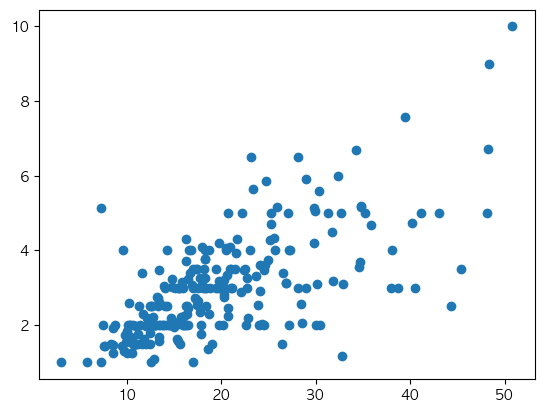

In [101]:
fig = plt.figure()
axes =fig.add_subplot(1,1,1)
axes.scatter(tips.total_bill, tips.tip)
plt.show()

### 2. box plot

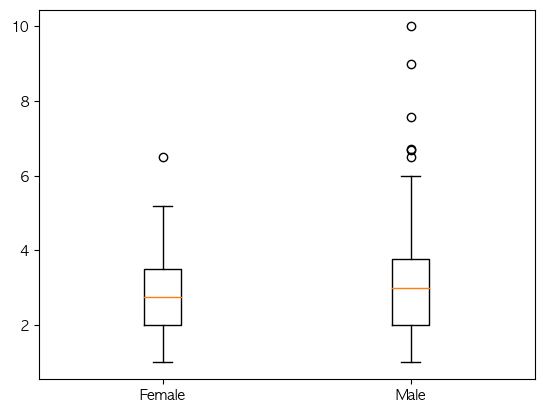

In [113]:
fig = plt.figure()
axes =fig.add_subplot(1,1,1)
axes.boxplot(
    x = [  tips[tips.sex=='Female'].tip,
           tips[tips.sex=='Male'].tip
        ],
    labels=['Female','Male']
)
plt.show()

## 3. 다변량 그래프

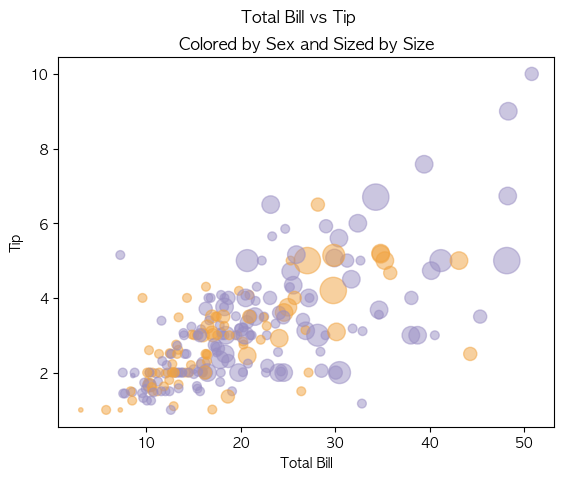

In [114]:
#map()함수에 사용
colors = {"Female": "#f1a340", "Male": "#998ec3"} # 성별에 따른 색상을 지정, 여성은 주황색, 남성은 보라색 
#16진수 코드는 https://www.w3schools.com/colors/colors_picker.asp 에서 확인 가능

scatter_plot = plt.figure()
axes1 = scatter_plot.add_subplot(1, 1, 1)

axes1.scatter(data=tips,
              x='total_bill',
              y='tip',
              s=tips['size']**2*10,# size를 제곱하여 점의 크기를 키움, s는 점의 크기를 나타내는 매개변수
              c=tips['sex'].map(colors),# map()은 Series의 각 요소에 대해 특정 함수를 적용할 때 사용, c는 점의 색을 나타내는 매개변수, colors 딕셔너리에 따라 여성은 주황색, 남성은 보라색
              alpha=0.5) # alpha는 점의 투명도를 나타내는 매개변수

axes1.set_title('Colored by Sex and Sized by Size')
axes1.set_xlabel('Total Bill')
axes1.set_ylabel('Tip')

scatter_plot.suptitle('Total Bill vs Tip')

plt.show()

# 3. seaborn

<AxesSubplot:xlabel='day', ylabel='count'>

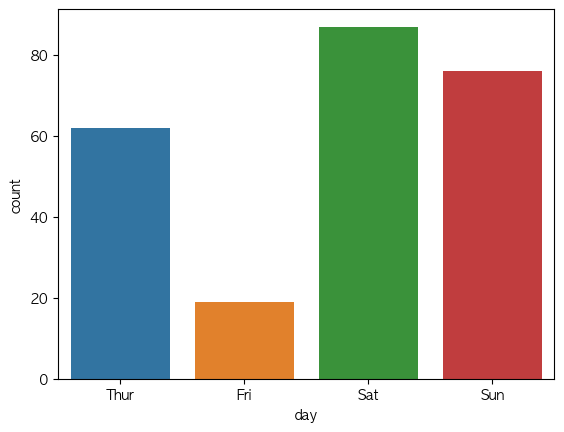

In [118]:
import seaborn as sns
fig = plt.figure()
axes =fig.add_subplot(1,1,1)
sns.countplot(data = tips, x='day')

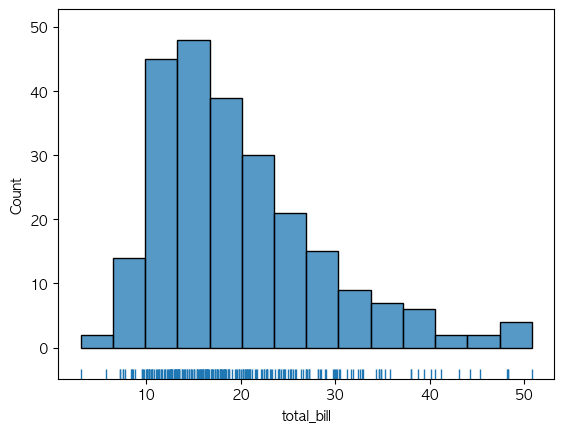

In [123]:
sns.rugplot(data=tips, x='total_bill')
sns.histplot(data=tips, x='total_bill')
plt.show()

<AxesSubplot:xlabel='day', ylabel='count'>

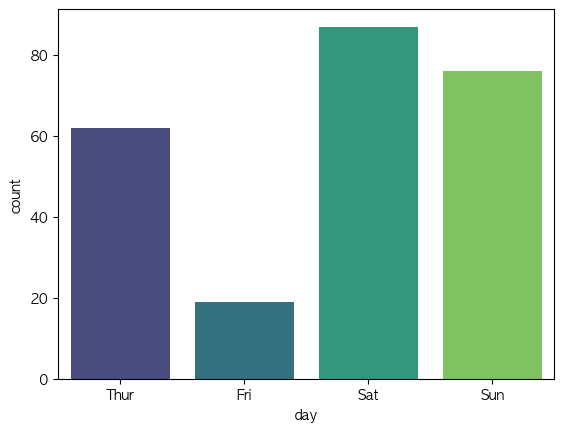

In [124]:
sns.countplot(data=tips,x='day',palette='viridis')

## 2. 이변향 그래프

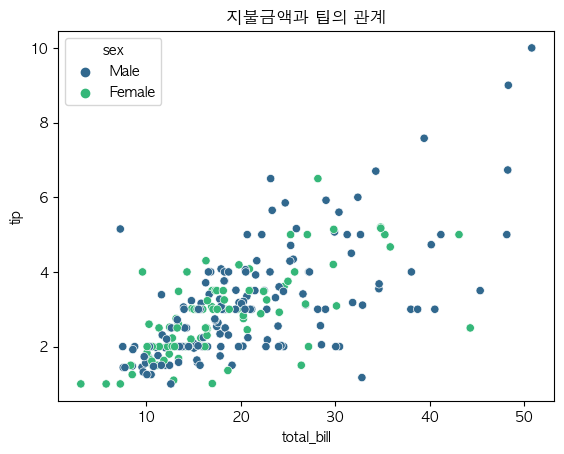

In [126]:
cnt, ax = plt.subplots()
sns.scatterplot(data=tips, x='total_bill', y='tip', ax=ax,hue='sex', palette='viridis')
ax.set_title('지불금액과 팁의 관계')
plt.show()

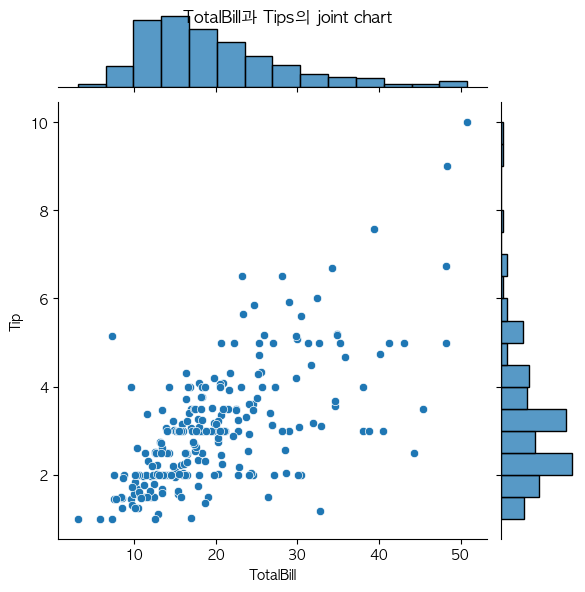

In [129]:
# joint plot

joint = sns.jointplot(data=tips, x='total_bill', y='tip')
joint.set_axis_labels(xlabel='TotalBill',ylabel = 'Tip')
joint.figure.suptitle('TotalBill과 Tips의 joint chart ')
plt.show()

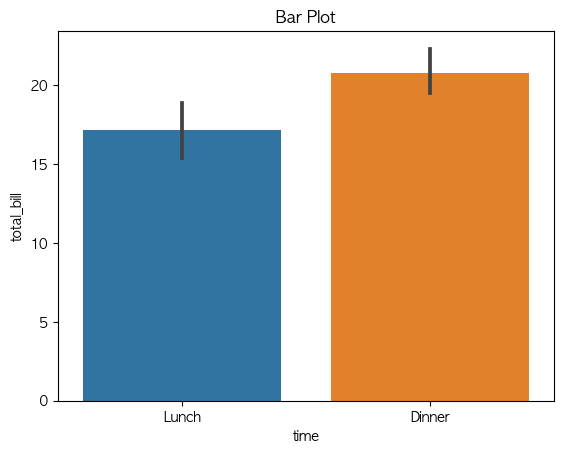

In [145]:
# bar plots 

bar, ax = plt.subplots()
sns.barplot(data=tips,x='time' ,y='total_bill', ax=ax) #default: estimator=np.mean
ax.set_title('Bar Plot')
plt.show()

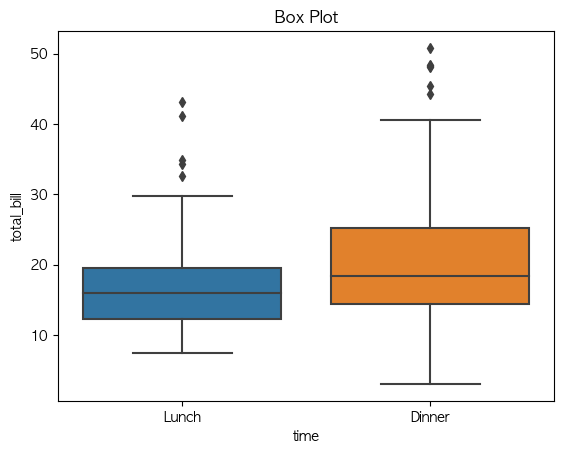

In [148]:
#box plots

bar, ax = plt.subplots()
sns.boxplot(data=tips,x='time' ,y='total_bill', ax=ax) 
ax.set_title('Box Plot')
plt.show()

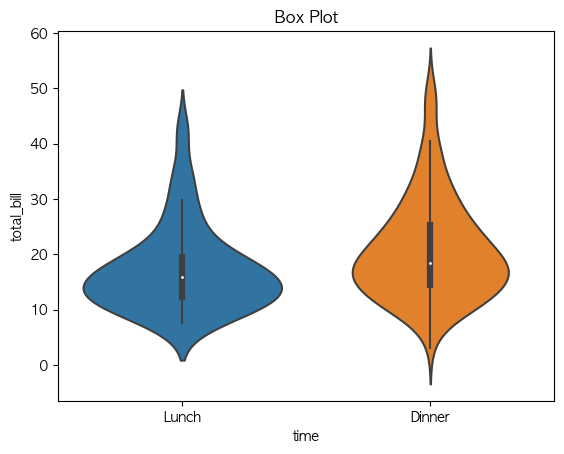

In [150]:
#violin plots

bar, ax = plt.subplots()
sns.violinplot(data=tips,x='time' ,y='total_bill', ax=ax) 
ax.set_title('Box Plot')
plt.show()

### 3. pair plot

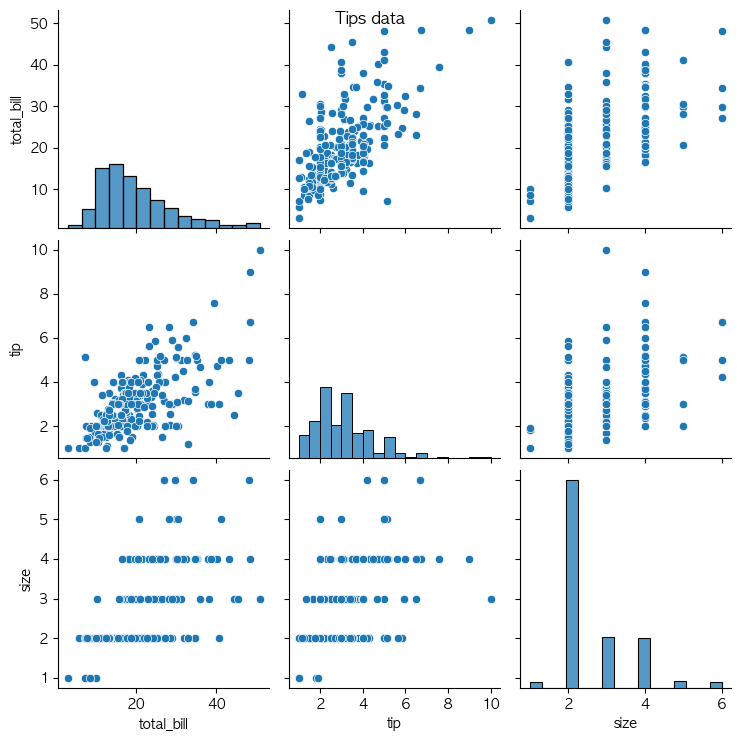

In [153]:
fig = sns.pairplot(data=tips)
fig.figure.suptitle('Tips data')
plt.show()